## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?

Regression predicts a continuous numerical value, such as price or temperature. Classification predicts a category or class, such as spam/not spam.

2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table compares the model's predicted classes with the actual classes. It shows which classes the model predicts correctly and which classes it tends to confuse.

3. What does the SSE quantify about a particular model?

SSE (Sum of Squared Errors) measures the total squared difference between the actual values and predicted values. A lower SSE generally means the predictions are closer to the actual values.

4. What are overfitting and underfitting? 

Overfitting happens when a model learns the training data too closely, including noise, so it performs poorly on new data. Underfitting happens when a model is too simple to capture important patterns in the data.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

The training set is used to build the model, while the testing set checks how well it performs on unseen data. Comparing different values of \(k\) helps us choose one that generalizes well instead of simply fitting the training data.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

A class label gives one clear prediction. It is simple and easy to interpret, but it does not tell us how confident the model is. 

A probability distribution might instead give something like 70% gold, 25% silver, and 5% bronze. This provides more information about the model's uncertainty and confidence, but it is more complicated to interpret and the probabilities may not always be well-calibrated.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Dylan Wang

**Date:** 9/27/2026

In [9]:
# Your Phase 1 solution to the problem goes here.

# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('data/land_mines.csv')
df.head(10)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
5,0.240966,0.727273,0.0,1
6,0.254410,0.818182,0.0,1
7,0.234924,1.000000,0.0,1
8,0.353474,0.000000,0.6,1
9,0.335347,0.181818,0.6,1


In [10]:
# question 1:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

Shape: (338, 4)

Data types:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Summary statistics:


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000



Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


### EDA
The dataset contains 338 observations. The target variable is `mine_type`, 
which has five possible classes from 1 to 5. The three features used to predict 
mine type are `voltage`, `height`, and `soil`.

The five mine types are fairly evenly distributed, with each class containing 
between 65 and 71 observations. The features are all numerical and are already 
on similar scales between approximately 0 and 1.

In [13]:
# question 2:
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5, # make them equal size 50 test 50 train
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTesting class counts:")
print(y_test.value_counts().sort_index())

Training size: 169
Testing size: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Testing class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


I split the data 50/50 into training and testing sets. I used stratification 
based on `mine_type` so that each mine type has approximately the same 
proportion in both sets.

In [16]:
# question 3:
k_values = range(1, 31)
accuracies = []

# loop through each k value, train the model, and calculate accuracy
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    accuracies.append(accuracy)

# get the best k
best_k = k_values[np.argmax(accuracies)]

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))


Best k: 2
Best accuracy: 0.4378698224852071


I tested values of k from 1 through 30 and compared their classification 
accuracy on the test set. The highest accuracy was obtained at k = 2, with 
an accuracy of about 43.8%. Therefore, I selected k = 2 for the final model.

In [22]:
# question 4:

best_model = KNeighborsClassifier(n_neighbors=best_k)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

confusion = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

confusion



Accuracy: 0.4378698224852071
Accuracy percentage: 43.79 %


Predicted,1,2,3,4,5
Actual,,,,,
1,25,0,6,4,1
2,0,32,0,3,0
3,12,2,9,6,4
4,12,5,8,8,0
5,15,2,10,5,0


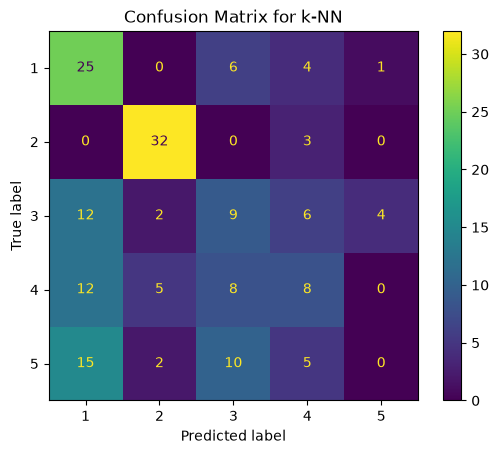

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix for k-NN")
plt.show()

The final model has an accuracy of about 43.8%. However, its performance 
varies significantly between mine types.

Mine type 2 is predicted very well, with 32 of 35 examples classified 
correctly. Mine type 1 also performs relatively well, with 25 of 36 classified 
correctly.

The model performs much worse for types 3, 4, and especially 5. None of the 
type 5 observations in this test split were correctly predicted as type 5. 
Many type 5 mines were instead classified as types 1 or 3.

Therefore, the overall accuracy does not fully describe the model's performance 
for each individual class.

### question 5
I would not recommend using this model as the only method for identifying a 
mine in practice. It could be a baseline model. 

Although it performs well for some classes, it makes many mistakes for others. For example, in this test set it failed to correctly identify any type 5 mines.

This is quite important because mine identification is a safety-critical 
problem. A wrong prediction could be much more serious than an error in a 
typical classification problem.

Instead, I would use the model as a supporting tool. I would also collect 
more data and improve the model before considering it for real-world use.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]